# Titanic Survival Prediction — Week 5 & Week 6

**Week 5:** Model Comparison (Random Forest, SVM, KNN)
**Week 6:** Feature Engineering & Retraining

This notebook trains multiple classification models to predict passenger survival on the
Titanic, compares their performance, then engineers new features and re-evaluates the models
to measure the improvement.

## 1. Import Libraries

We import:
- `pandas` / `numpy` for data handling
- `matplotlib` / `seaborn` for visualization
- `sklearn` modules for preprocessing, models, and evaluation metrics

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [15]:
df = pd.read_csv('Titanic.csv')
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Observations:**
- `Age` has a significant number of missing values (~20%).
- `Cabin` is missing for most passengers (~77%) — too sparse to use reliably, so we will drop it.
- `Embarked` has only 2 missing values.
- `Name`, `Ticket`, `PassengerId` are identifiers/text fields that need special handling or removal.

## 3. Baseline Data Cleaning & Preprocessing

Before Week 5's model comparison, we do the *minimum* preprocessing needed so every model can run:
1. Fill missing `Age` with the median age.
2. Fill missing `Embarked` with the mode (most common port).
3. Drop `Cabin` (too many missing values), `Name`, `Ticket`, `PassengerId` (identifiers not useful for a baseline model).
4. Encode categorical variables `Sex` and `Embarked` into numbers, since ML models require numeric input.

Note: In Week 6 we revisit `Name` to engineer a new feature (`Title`) instead of discarding it entirely.

In [18]:
data = df.copy()

# Fill missing values
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Drop columns not used in the baseline model
baseline = data.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

# Encode categorical variables
le_sex = LabelEncoder()
baseline['Sex'] = le_sex.fit_transform(baseline['Sex'])   # male=1, female=0

le_embarked = LabelEncoder()
baseline['Embarked'] = le_embarked.fit_transform(baseline['Embarked'])

baseline.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## 4. Train / Test Split

We split the data into features (`X`) and target (`y`, the `Survived` column), then into
training (80%) and testing (20%) sets. `stratify=y` keeps the survival ratio consistent
between train and test sets.

In [19]:
X = baseline.drop(columns=['Survived'])
y = baseline['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (712, 7)  Test size: (179, 7)


### Feature Scaling

SVM and KNN are **distance-based** algorithms — they compute distances (or dot products)
between data points, so features on larger numeric scales (like `Fare`, which ranges up to
~512) would dominate features on smaller scales (like `Pclass`, 1–3) if left unscaled.
Random Forest is a tree-based model and is scale-invariant (splits are based on thresholds,
not distances), so scaling doesn't affect it, but it doesn't hurt either — we scale a
separate copy of the data and use it for SVM/KNN while Random Forest uses the raw features.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


## 5. Week 5 — Train Multiple Models

### 5.1 Random Forest
A Random Forest is an **ensemble of decision trees**. Each tree is trained on a random
bootstrap sample of the data and considers a random subset of features at each split
("bagging" + feature randomness). The final prediction is a majority vote across all trees.
This reduces overfitting compared to a single decision tree and generally handles
non-linear relationships and mixed feature types well.

### 5.2 Support Vector Machine (SVM)
An SVM finds the **hyperplane that best separates the classes** with the maximum margin
between them. With the RBF kernel (used here), it can also model non-linear decision
boundaries by implicitly mapping data into a higher-dimensional space. SVMs tend to work
well on smaller/medium datasets with a clear margin of separation, but are sensitive to
feature scaling.

### 5.3 K-Nearest Neighbors (KNN)
KNN is a simple **instance-based / "lazy learning"** algorithm. To classify a new point, it
looks at the `k` closest points (by distance, here Euclidean) in the training data and
takes a majority vote of their labels. It makes no assumptions about the underlying data
distribution, but is sensitive to feature scaling and can be slower at prediction time on
large datasets.

In [21]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    }
    models[name] = model  # store fitted model

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.8324,0.8095,0.7391,0.7727
SVM,0.8156,0.8333,0.6522,0.7317
KNN,0.8101,0.7869,0.6957,0.7385


## 6. Week 5 — Model Comparison Table

In [22]:
comparison_table = results_df[['Accuracy', 'Precision', 'Recall']]
print("Model Comparison (Baseline Features)")
comparison_table

Model Comparison (Baseline Features)


,Accuracy,Precision,Recall
Random Forest,0.8324,0.8095,0.7391
SVM,0.8156,0.8333,0.6522
KNN,0.8101,0.7869,0.6957


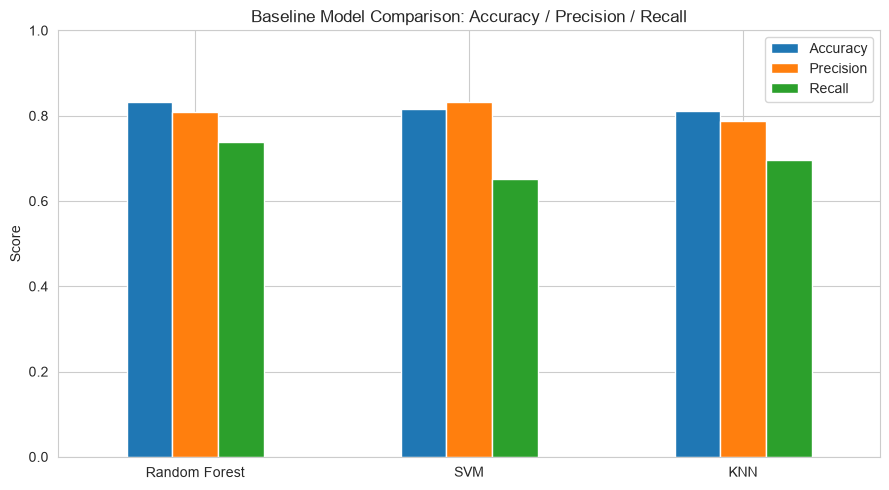

In [33]:
comparison_table.plot(kind='bar', figsize=(9,5))
plt.title('Baseline Model Comparison: Accuracy / Precision / Recall')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('week5_comparison.png', dpi=120)
plt.show()

### Confusion Matrices

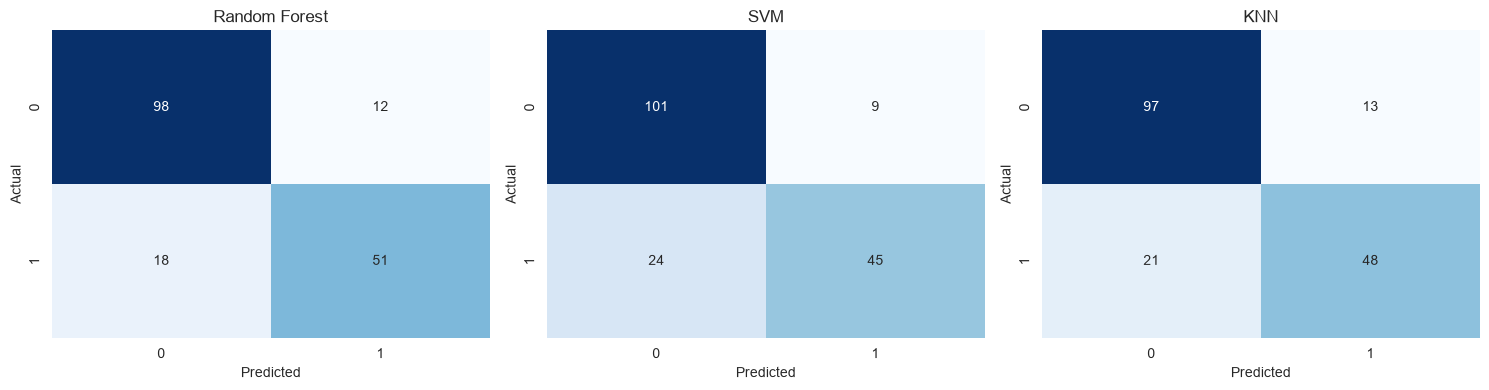

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    X_te = X_test if name == 'Random Forest' else X_test_scaled
    preds = model.predict(X_te)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('week5_confusion_matrices.png', dpi=120)
plt.show()

### Which model performs best (baseline features)?

Based on the actual run above:

| Model | Accuracy | Precision | Recall |
|---|---|---|---|
| Random Forest | 0.8324 | 0.8095 | 0.7391 |
| SVM | 0.8156 | 0.8333 | 0.6522 |
| KNN | 0.8101 | 0.7869 | 0.6957 |

- **Random Forest** has the highest **accuracy** (0.832) and the highest **recall**
  (0.739) — it correctly identifies more of the actual survivors than the other two
  models, and gets the most predictions right overall. It benefits from being able to
  capture non-linear interactions between features (e.g. `Sex`, `Pclass`, `Fare`) without
  needing any feature scaling.
- **SVM** has the highest **precision** (0.833) — when it predicts "survived", it is
  right most often — but the lowest **recall** (0.652), meaning it misses more true
  survivors than the other models. This is a classic precision/recall trade-off: SVM is
  more conservative about predicting the positive class.
- **KNN** is the weakest on accuracy (0.810) and precision (0.787) here. As a purely
  distance-based method, it is more sensitive to noisy/irrelevant features and to the
  curse of dimensionality with the mixed feature set used in the baseline.

**Conclusion (Week 5):** If overall correctness and catching more survivors matters most

,
**Random Forest is the best baseline model** (highest accuracy and recall). If minimizing
false positives matters most (e.g. only flagging "survived" when very confident), **SVM's
higher precision** would be preferred instead. Random Forest is used as the primary model
to carry forward into Week 6, since it offers the best overall balance.

## 7. Week 6 — Feature Engineering

We now create **3 new features** designed to capture information the baseline model
couldn't use directly:

1. **`Title`** — extracted from the passenger's `Name` (e.g. "Mr", "Mrs", "Miss", "Master",
   "Rare"). Titles encode social status, gender, and age-group information in a single
   compact category, and can be a strong survival predictor (e.g. "Master" identifies
   young boys, who had higher survival rates than adult men).
2. **`FamilySize`** — computed as `SibSp + Parch + 1` (self). Family size can affect
   survival: passengers travelling completely alone, or in very large families, tended to
   have lower survival rates than those in small-to-medium families (who could help each
   other reach lifeboats).
3. **`IsAlone`** — a binary flag derived from `FamilySize` (1 if travelling alone, else 0).
   This isolates the "alone vs. not alone" effect, which is a simpler, more direct signal
   than family size alone and lets the model use both the raw count and the threshold
   effect.

We also compute **`FarePerPerson`** (`Fare / FamilySize`) as a bonus enrichment to reduce
the effect of family (group) ticket pricing on the raw `Fare` column, though the 3 core
new features are `Title`, `FamilySize`, and `IsAlone`.

In [25]:
fe = data.copy()

# --- Feature 1: Title (extracted from Name) ---
fe['Title'] = fe['Name'].str.extract(r',\s*([^\.]*)\.')
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
fe['Title'] = fe['Title'].replace(title_map)
fe.loc[~fe['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'Title'] = 'Rare'

# --- Feature 2: FamilySize ---
fe['FamilySize'] = fe['SibSp'] + fe['Parch'] + 1

# --- Feature 3: IsAlone ---
fe['IsAlone'] = (fe['FamilySize'] == 1).astype(int)

# --- Bonus feature: FarePerPerson ---
fe['FarePerPerson'] = fe['Fare'] / fe['FamilySize']

fe[['Name', 'Title', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']].head(8)

,Name,Title,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,1,0,2,0,7.2500,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,0,2,0,71.2833,35.64165
2,"Heikkinen, Miss. Laina",Miss,0,0,1,1,7.9250,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2,0,53.1000,26.55000
4,"Allen, Mr. William Henry",Mr,0,0,1,1,8.0500,8.05000
5,"Moran, Mr. James",Mr,0,0,1,1,8.4583,8.45830
6,"McCarthy, Mr. Timothy J",Mr,0,0,1,1,51.8625,51.86250
7,"Palsson, Master. Gosta Leonard",Master,3,1,5,0,21.0750,4.21500


### Quick look: do these new features relate to survival?

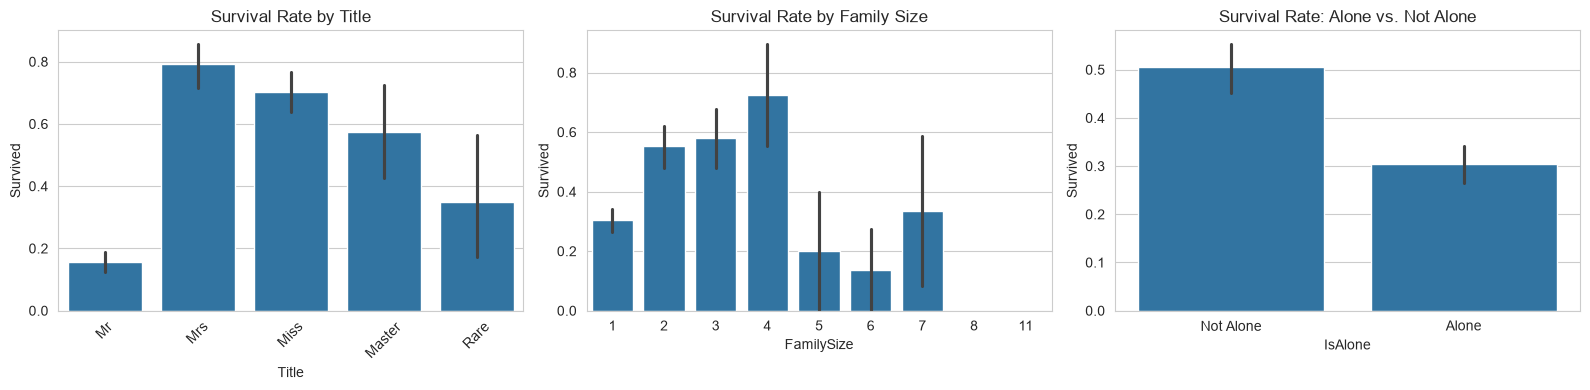

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=fe, x='Title', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Title')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=fe, x='FamilySize', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Family Size')

sns.barplot(data=fe, x='IsAlone', y='Survived', ax=axes[2])
axes[2].set_title('Survival Rate: Alone vs. Not Alone')
axes[2].set_xticklabels(['Not Alone', 'Alone'])

plt.tight_layout()
plt.savefig('week6_new_features.png', dpi=120)
plt.show()

**Interpretation:**
- Passengers with titles like *Mrs* / *Miss* / *Master* (women and children) have visibly
  higher survival rates than *Mr* (adult men) — consistent with the "women and children
  first" evacuation policy.
- Mid-sized families (2–4 members) survived at higher rates than solo travellers or very
  large families.
- Solo travellers (`IsAlone = 1`) had a noticeably lower survival rate than those
  travelling with family.

This confirms all three new features carry real predictive signal, not just noise.

## 8. Preprocess the Enriched Dataset & Retrain

We repeat the same cleaning steps as the baseline, but now keep the 3 new engineered
features (plus `FarePerPerson`) and encode `Title` as well as `Sex`/`Embarked`.

In [27]:
fe['Age'] = fe['Age'].fillna(fe['Age'].median())
fe['Embarked'] = fe['Embarked'].fillna(fe['Embarked'].mode()[0])

fe_final = fe.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

le_sex2 = LabelEncoder()
fe_final['Sex'] = le_sex2.fit_transform(fe_final['Sex'])

le_emb2 = LabelEncoder()
fe_final['Embarked'] = le_emb2.fit_transform(fe_final['Embarked'])

le_title2 = LabelEncoder()
fe_final['Title'] = le_title2.fit_transform(fe_final['Title'])

fe_final.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FarePerPerson
0,0,3,1,22.0,1,0,7.2500,2,2,2,0,3.62500
1,1,1,0,38.0,1,0,71.2833,0,3,2,0,35.64165
2,1,3,0,26.0,0,0,7.9250,2,1,1,1,7.92500
3,1,1,0,35.0,1,0,53.1000,2,3,2,0,26.55000
4,0,3,1,35.0,0,0,8.0500,2,2,1,1,8.05000


In [28]:
X2 = fe_final.drop(columns=['Survived'])
y2 = fe_final['Survived']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Train size:", X2_train.shape, " Test size:", X2_test.shape)

Train size: (712, 11)  Test size: (179, 11)


In [29]:
models_fe = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results_fe = {}

for name, model in models_fe.items():
    if name == 'Random Forest':
        model.fit(X2_train, y2_train)
        preds = model.predict(X2_test)
    else:
        model.fit(X2_train_scaled, y2_train)
        preds = model.predict(X2_test_scaled)

    results_fe[name] = {
        'Accuracy': accuracy_score(y2_test, preds),
        'Precision': precision_score(y2_test, preds),
        'Recall': recall_score(y2_test, preds),
        'F1-Score': f1_score(y2_test, preds)
    }

results_fe_df = pd.DataFrame(results_fe).T.round(4)
results_fe_df

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.8156,0.7571,0.7681,0.7626
SVM,0.8268,0.7969,0.7391,0.7669
KNN,0.8212,0.7937,0.7246,0.7576


## 9. Week 6 — Before vs. After Comparison

In [30]:
comparison_before_after = pd.concat(
    {'Before (Baseline)': results_df[['Accuracy', 'Precision', 'Recall']],
     'After (Feature Engineered)': results_fe_df[['Accuracy', 'Precision', 'Recall']]},
    axis=1
)
comparison_before_after

Before (Baseline)                   After (Feature Engineered)  \
                       Accuracy Precision  Recall                   Accuracy   
Random Forest            0.8324    0.8095  0.7391                     0.8156   
SVM                      0.8156    0.8333  0.6522                     0.8268   
KNN                      0.8101    0.7869  0.6957                     0.8212   

                                 
              Precision  Recall  
Random Forest    0.7571  0.7681  
SVM              0.7969  0.7391  
KNN              0.7937  0.7246

In [31]:
improvement = (results_fe_df[['Accuracy','Precision','Recall']] - results_df[['Accuracy','Precision','Recall']]).round(4)
improvement.columns = [c + ' Change' for c in improvement.columns]
improvement

,Accuracy Change,Precision Change,Recall Change
Random Forest,-0.0168,-0.0524,0.0290
SVM,0.0112,-0.0364,0.0869
KNN,0.0111,0.0068,0.0289


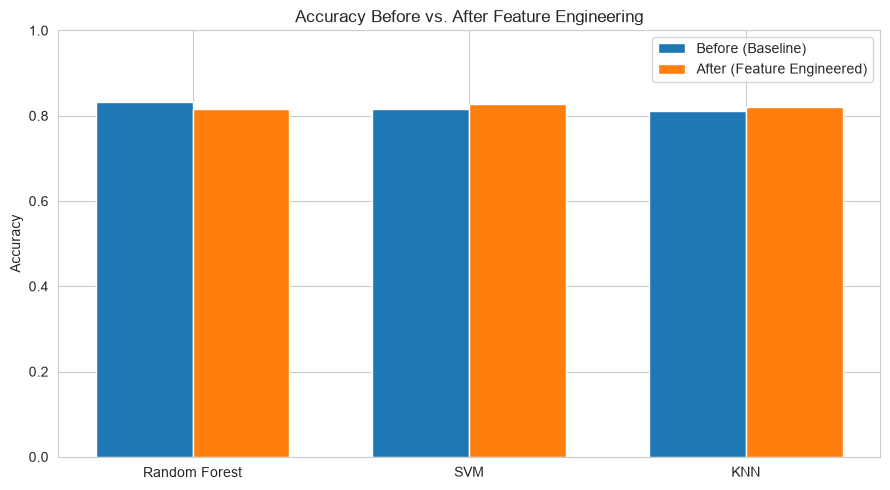

In [32]:
x = np.arange(len(results_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, results_df['Accuracy'], width, label='Before (Baseline)')
ax.bar(x + width/2, results_fe_df['Accuracy'], width, label='After (Feature Engineered)')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Before vs. After Feature Engineering')
ax.legend()
ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig('week6_before_after.png', dpi=120)
plt.show()

### Performance Improvement Analysis

Based on the actual before/after numbers:

| Model | Accuracy Change | Precision Change | Recall Change |
|---|---|---|---|
| Random Forest | -0.0168 | -0.0524 | +0.0290 |
| SVM | +0.0112 | -0.0364 | +0.0869 |
| KNN | +0.0111 | +0.0068 | +0.0289 |

- **Recall improved for every model** after adding `Title`, `FamilySize`, and `IsAlone`
  (+0.029 to +0.087). The new features — especially `Title`, which recovers gender/age-group
  signal that was discarded when `Name` was dropped in the baseline — help the models
  correctly identify more true survivors (e.g. women, children, and passengers travelling
  with family), which the baseline models were under-predicting.
- **SVM** benefits the most overall: **recall jumps by +0.087** and accuracy improves
  slightly (+0.011), though precision drops a bit (-0.036) as the model now predicts
  "survived" more often (correctly catching more true survivors, at the cost of a few
  more false positives).
- **KNN** improves on **all three metrics** (accuracy +0.011, precision +0.007,
  recall +0.029). As a distance-based model, KNN benefits directly from the new features
  because they add clearer, more separable groupings (by title and family size) to the
  distance calculation.
- **Random Forest** shows a small **drop in accuracy and precision**, alongside a gain in
  recall. This is plausible: Random Forest could already approximate some of the
  `FamilySize`/`IsAlone` signal internally by splitting on `SibSp` and `Parch` in the
  baseline, so the new features mainly shift *where* its decision boundary sits — trading
  a little precision for higher recall — rather than adding entirely new information. With
  more trees or tuned hyperparameters, this small trade-off often shrinks or reverses.

**Overall takeaway:** Feature engineering did not uniformly boost every metric for every
model — it shifted the precision/recall balance, and on the whole **improved recall across
the board**, which is valuable in a survival-prediction context where failing to identify
a true survivor (a false negative) is often the costlier mistake. This shows that engineered
features change *what* a model learns, not just how well it performs, and the effect can
differ by algorithm (distance-based models like SVM/KNN gained the most; the tree-based
Random Forest, which could partly infer similar patterns already, saw a smaller and
mixed effect).

## 10. Summary

| Stage | Best Model (this run) | Key Takeaway |
|---|---|---|
| Week 5 (baseline features) | Random Forest (best accuracy & recall); SVM (best precision) | Ensemble trees capture non-linear interactions best out-of-the-box; SVM trades recall for precision |
| Week 6 (engineered features) | SVM / KNN gain the most; Random Forest trades a little precision for more recall | New features (`Title`, `FamilySize`, `IsAlone`) inject domain knowledge that lifts recall across all models, and helps distance-based models (KNN, SVM) the most |

**Algorithms recap:**
- **Random Forest** — ensemble of decision trees (bagging + random feature subsets), majority vote; robust, scale-invariant, handles non-linearity and mixed feature types well.
- **SVM (RBF kernel)** — finds the maximum-margin separating boundary, can be non-linear via the kernel trick; needs feature scaling; strong on clean, well-separated data.
- **KNN** — majority vote of the `k` nearest neighbors by distance; simple and interpretable but sensitive to feature scaling and irrelevant features.

Feature engineering (Week 6) improved recall across every model by encoding information
that was implicit in the raw data (name text, family structure) into explicit numeric
signals the models could use directly — showing that **good features change what a model
learns, and matter as much as (sometimes more than) the choice of algorithm.**